In [27]:
#Libraries import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA

In [28]:
# Data-information
df = pd.read_csv('/content/tesla_deliveries_dataset_2015_2025.csv')
print(df.head())
print("Shape:", df.shape)

   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               7640  
2          

In [29]:
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
None

Missing Values:
Year                    0
Month                   0
Region                  0
Model          

In [30]:
# Identify Numeric and Categorical Columns
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numeric Columns:\n", numeric_cols)
print("\nCategorical Columns:\n", categorical_cols)

Numeric Columns:
 Index(['Year', 'Month', 'Estimated_Deliveries', 'Production_Units',
       'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
       'Charging_Stations'],
      dtype='object')

Categorical Columns:
 Index(['Region', 'Model', 'Source_Type'], dtype='object')


In [31]:
#Encode categorical columns
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print(df.dtypes)

Year                      int64
Month                     int64
Region                    int64
Model                     int64
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type               int64
Charging_Stations         int64
dtype: object


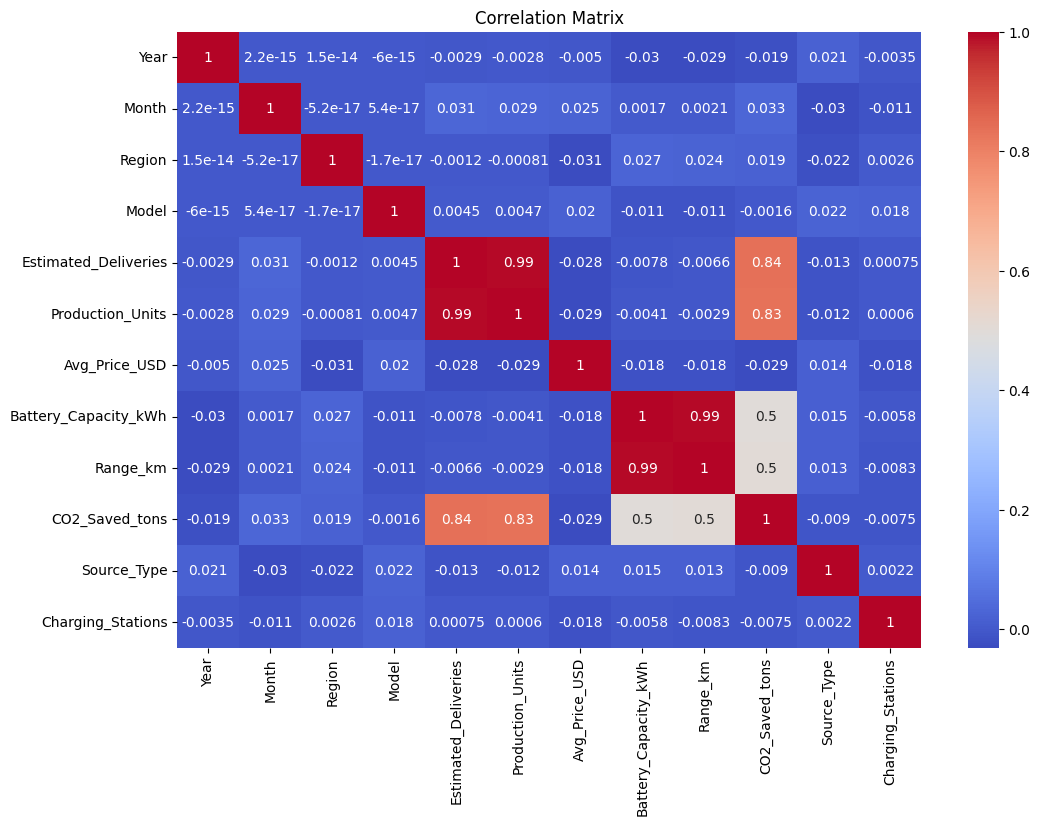

In [32]:
# Data Visualization using heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

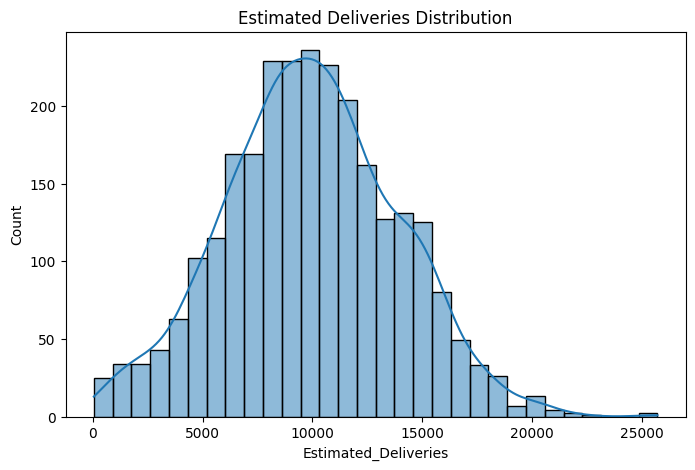

In [33]:
#Estimated Deliveries Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Estimated_Deliveries'], bins=30, kde=True)
plt.title("Estimated Deliveries Distribution")
plt.show()

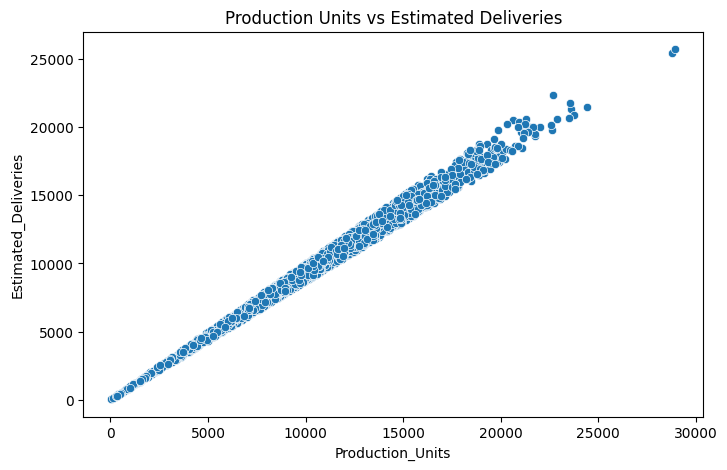

In [34]:
#Production vs Estimated_Deliveries
plt.figure(figsize=(8,5))
sns.scatterplot(x='Production_Units', y='Estimated_Deliveries', data=df)
plt.title("Production Units vs Estimated Deliveries")
plt.show()

In [35]:
#Train Test Split
X = df.drop('Estimated_Deliveries', axis=1)
y = df['Estimated_Deliveries']

print("Features Used:")
print(X.columns.tolist())

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Features Used:
['Year', 'Month', 'Region', 'Model', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


In [36]:
#Linear Regression model train and evaluate
lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_lr)))
print("R2:", r2_score(y_test, pred_lr))

Linear Regression
MAE: 310.1300215468215
RMSE: 383.5765698703907
R2: 0.9901296027802067


In [37]:
#Ridge regression model train and evaluate
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

pred_ridge = ridge.predict(X_test)

print("Ridge Regression")
print("MAE:", mean_absolute_error(y_test, pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_ridge)))
print("R2:", r2_score(y_test, pred_ridge))

Ridge Regression
MAE: 310.12989239267165
RMSE: 383.57634399111225
R2: 0.9901296144050958


In [38]:
#Lasso regression model train and evaluate
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

pred_lasso = lasso.predict(X_test)

print("Lasso Regression")
print("MAE:", mean_absolute_error(y_test, pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_lasso)))
print("R2:", r2_score(y_test, pred_lasso))

Lasso Regression
MAE: 310.1225399359182
RMSE: 383.56375591814884
R2: 0.9901302622401211


In [39]:
#Random forest model train and evaluate
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest")
print("MAE:", mean_absolute_error(y_test, pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rf)))
print("R2:", r2_score(y_test, pred_rf))

Random Forest
MAE: 319.9504071969697
RMSE: 406.13059878196583
R2: 0.9889347326587142


In [40]:
#Hyperparameter tuning
params = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,15,None],
    'min_samples_split':[2,5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=5,
    scoring='r2'
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 300}


                 Feature  Importance
4       Production_Units    0.990799
8         CO2_Saved_tons    0.002323
7               Range_km    0.001443
5          Avg_Price_USD    0.001340
10     Charging_Stations    0.001127
0                   Year    0.000854
1                  Month    0.000768
3                  Model    0.000477
2                 Region    0.000412
9            Source_Type    0.000300
6   Battery_Capacity_kWh    0.000158


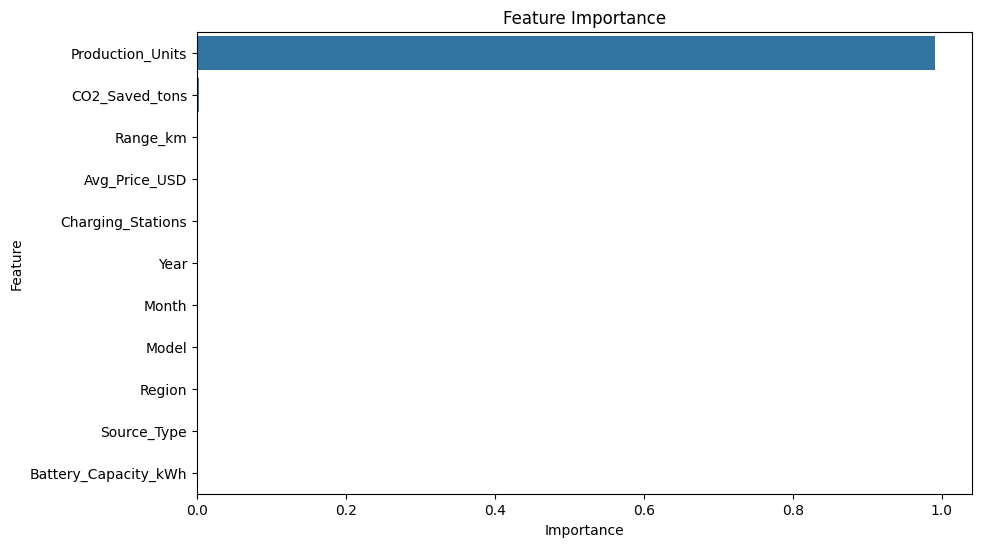

In [41]:
#Feature Importance
best_rf = grid.best_estimator_

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)
plt.title("Feature Importance")
plt.show()

In [42]:
#Time Series Forecasting
ts = df.groupby('Year')['Estimated_Deliveries'].sum()

model = ARIMA(ts, order=(2,1,2))
model_fit = model.fit()

forecast = model_fit.forecast(steps=5)

print("Forecast for next 5 years:")
print(forecast)

Forecast for next 5 years:
11    2.299894e+06
12    2.409983e+06
13    2.411338e+06
14    2.323992e+06
15    2.364693e+06
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as s

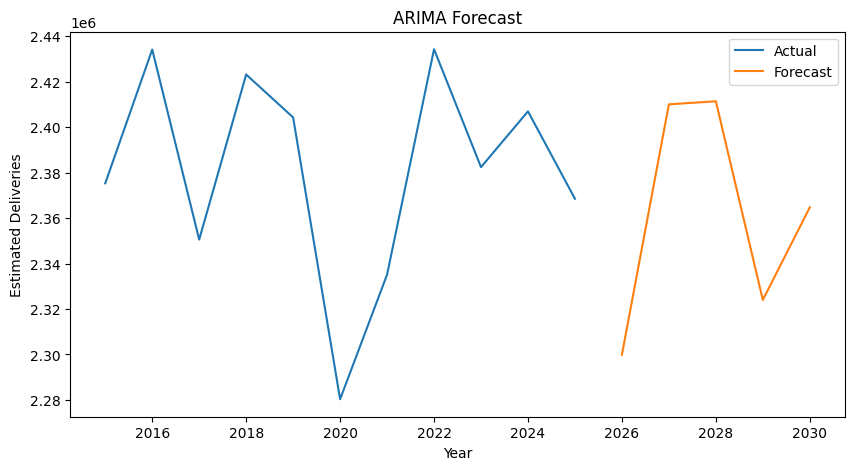

In [43]:
#Forecast Visualization
plt.figure(figsize=(10,5))

plt.plot(ts.index, ts.values, label='Actual')

future_years = [
    ts.index.max() + i
    for i in range(1,6)
]

plt.plot(
    future_years,
    forecast,
    label='Forecast'
)

plt.xlabel('Year')
plt.ylabel('Estimated Deliveries')
plt.title('ARIMA Forecast')
plt.legend()
plt.show()